# ℓ1 uncertainty sets: the quintile and 1/N portfolios

Two of the most stubbornly popular portfolios in practice have no theory behind them. The
**1/N portfolio** puts `1/N` in every asset and ignores the market entirely. The **quintile
portfolio** sorts assets by some characteristic — momentum, value, low volatility — and
equally longs the top 20%, sometimes shorting the bottom 20%. Both are routinely dismissed as
naive, and both routinely beat the theory-based portfolios they are compared against.

Zhou & Palomar [quintile](@cite) show they are not naive at all. They are the **exact
solutions** of a robust optimisation problem: maximise the worst-case characteristic when the
true characteristic lies somewhere in an ℓ1 ball around your estimate. The ball's radius `ε`
is the *only* dial, and it decides how many assets you hold:

| radius | portfolio | active assets |
|:--|:--|:--|
| `ε → 0` | trust the estimate completely | 1 (the single best asset) |
| `ε` moderate | quintile portfolio | ~20% |
| `ε` large | give up on the estimate | all of them, equally weighted (1/N) |

So the quintile portfolio is what you get when you *half* believe your return forecast, and
the 1/N portfolio is what you get when you do not believe it at all. Neither is a heuristic;
they are the answers to a question nobody realised they were asking.

Because of that, this library ships **no quintile optimiser**. An ℓ1 ball is an
[uncertainty set](09_Uncertainty_Sets.md), so the quintile portfolio is an ordinary
`MeanRisk` problem with a particular `ucs` — and it composes with every constraint in
the library for free (ADR 0032). This page is a deep dive: the ε sweep that produces the table
above, all of the paper's models, ranking on a characteristic other than return, and the
classical portfolios the paper benchmarks against.

> **When to reach for this**
>
> Reach for an ℓ1 set when you have a *ranking* you half-trust. Its ergonomics are unusual:
> rather than tuning `ε` (which has no meaningful scale — see section 3), you say how many
> assets you want to hold and let `ActiveAssetsUncertaintyAlgorithm` solve for the
> radius. Reach for a [box or ellipsoidal set](09_Uncertainty_Sets.md) instead when you want
> to be robust to the *magnitude* of estimation error rather than to the ranking.

In [1]:
using PortfolioOptimisers, PrettyTables, StatsPlots, Statistics, LinearAlgebra, HiGHS,
      Clarabel

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, AbstractFloat) ? "$(round(v*100, digits=2)) %" : v
    end
end;

## 1. Data and solver

The same S&P 500 slice as the other examples. Every model on this page is a **linear
program** — the worst case over an ℓ1 ball is an infinity norm, and an infinity norm is linear
once epigraphed — so HiGHS is all we need. No conic solver, no quadratic term.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = Solver(; name = :highs, solver = HiGHS.Optimizer,
             check_sol = (; allow_local = true, allow_almost = true),
             settings = Dict("log_to_console" => false))

N = size(rd.X, 2)

20

## 2. The recipe

Three pieces do the work:

  - `ArithmeticReturn` with a `ucs` — makes the return *worst-case* rather than nominal.
  - `MaximumReturn` — the objective. There is no risk term in this problem at all.
  - `NoRisk` — says so explicitly.

That last one deserves a word. `MeanRisk` requires a risk measure, so without `NoRisk` the
default `Variance` would be built and then thrown away by the objective — dragging
second-order cone constraints into a linear program and forcing a conic solver on it.
`NoRisk` contributes nothing and keeps the problem an LP.

In [3]:
function quintile(ucs; kwargs...)
    opt = JuMPOptimiser(; pe = pr, slv = slv, ret = ArithmeticReturn(; ucs = ucs),
                        kwargs...)
    return optimise(MeanRisk(; opt = opt, r = NoRisk(), obj = MaximumReturn()))
end

long_only(ucs) = quintile(ucs; bgt = 1.0, wb = WeightBounds(; lb = 0.0, ub = 1.0)).w;

## 3. The radius has no scale — so do not pick it by hand

`ε` is dimensionally a *sum of characteristic differences*, so its scale is inherited from the
data rather than being a property of the model. On the daily returns below the interesting
values live around `10⁻³`; on annualised returns everything shifts by ~250×. There is no
memorable "sensible" number, and the intuition you have for percentages is actively
misleading: `ε = 0.05` *looks* like a modest 5% of something, but here it is close to the top
of the range and gives essentially the 1/N portfolio.

Watch what the whole useful range actually looks like:

In [4]:
mu_sorted = sort(pr.mu; rev = true)
# The radius at which the k-th asset joins the portfolio (Lemma 2 of the paper).
ladder(k) = sum(mu_sorted[i] - mu_sorted[k] for i in 1:k)

pretty_table(DataFrame(;
                       portfolio = ["single best asset", "quintile (20%)", "half (50%)",
                                    "1/N (everything)"],
                       radius = [ladder(2) / 2, (ladder(4) + ladder(5)) / 2,
                                 (ladder(10) + ladder(11)) / 2, ladder(N)]);
             formatters = [(v, i, j) -> isa(v, Number) ? string(round(v; sigdigits = 3)) : v])

┌───────────────────┬──────────┐
│         portfolio │   radius │
│            String │  Float64 │
├───────────────────┼──────────┤
│ single best asset │ 0.000346 │
│    quintile (20%) │  0.00213 │
│        half (50%) │   0.0107 │
│  1/N (everything) │   0.0591 │
└───────────────────┴──────────┘


The entire span from "one asset" to "all of them" lives inside `[0, 0.06]`. This is why you
should not tune `ε` directly, and why `ActiveAssetsUncertaintyAlgorithm` exists: it
inverts the paper's closed forms so you specify the thing you actually have an opinion about —
*how many assets do I want to hold?* — and it solves for the radius.

> **It is a calibration, not a constraint**
>
> `active = 0.2` selects the radius that would activate 20% of assets on the *bare* problem
> (budget and sign constraints, nothing else). Add weight bounds, cardinality, or sector
> constraints — which is the entire point of this being an uncertainty set — and the realised
> count can differ. It is a unit conversion for an opaque parameter, not a promise. If you
> need a hard bound on the number of holdings, use `card`.

In [5]:
ue = CharacteristicUncertaintySet(; pe = EmpiricalPrior(),
                                  alg = L1UncertaintySetAlgorithm(;
                                                                  method = ActiveAssetsUncertaintyAlgorithm(;
                                                                                                            active = 0.2)))
mu_ucs(ue, rd)

L1UncertaintySet
  eps ┼ Float64: 0.0021257470647240173
   sd ┴ nothing


## 4. The ε sweep: one dial, three portfolios

This is the paper's central claim, reproduced. We sweep the radius from "trust the estimate"
to "distrust it entirely" and watch the portfolio walk from a single asset to 1/N — with the
quintile portfolio sitting in the middle, not as an approximation but as the exact optimum.

In [6]:
targets = 1:N
sweep = map(targets) do q
    alg = L1UncertaintySetAlgorithm(;
                                    method = ActiveAssetsUncertaintyAlgorithm(; active = q))
    eps = mu_ucs(CharacteristicUncertaintySet(; alg = alg), rd).eps
    w = long_only(L1UncertaintySet(; eps = eps))
    return (; q = q, eps = eps, active = count(>(1e-6), w), max_weight = maximum(w),
            hhi = sum(abs2, w))
end
sweep_df = DataFrame(sweep)

pretty_table(sweep_df[[1, 2, 4, 8, 12, 20], :];
             formatters = [(v, i, j) -> if isa(v, AbstractFloat)
                               string(round(v; sigdigits = 3))
                           else
                               v
                           end])

┌───────┬──────────┬────────┬────────────┬─────────┐
│     q │      eps │ active │ max_weight │     hhi │
│ Int64 │  Float64 │  Int64 │    Float64 │ Float64 │
├───────┼──────────┼────────┼────────────┼─────────┤
│     1 │ 0.000346 │      1 │        1.0 │     1.0 │
│     2 │ 0.000813 │      2 │        0.5 │     0.5 │
│     4 │  0.00213 │      4 │       0.25 │    0.25 │
│     8 │  0.00795 │      8 │      0.125 │   0.125 │
│    12 │    0.014 │     12 │     0.0833 │  0.0833 │
│    20 │   0.0744 │     20 │       0.05 │    0.05 │
└───────┴──────────┴────────┴────────────┴─────────┘


The realised active count tracks the request exactly, and the largest weight falls as `1/m` —
the portfolio is always *equally weighted over its active set*, which is the quintile
construction. Plotted against the radius:

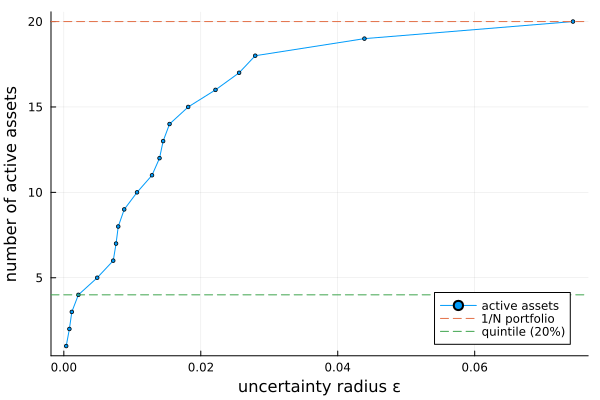

In [7]:
plot(sweep_df.eps, sweep_df.active; label = "active assets",
     xlabel = "uncertainty radius ε", ylabel = "number of active assets",
     legend = :bottomright, marker = :circle, markersize = 2)
hline!([N]; label = "1/N portfolio", linestyle = :dash)
hline!([round(Int, 0.2 * N)]; label = "quintile (20%)", linestyle = :dash)

## 5. Equal weights or inverse volatility? The `scaled` flag

The ball above assumes every asset's characteristic is estimated equally badly. That is a
strong assumption — a volatile asset's mean return is obviously harder to pin down than a
placid one's. Scaling the ball by each asset's volatility (`scaled = true`, the paper's `A₁`
set) encodes that, and the optimum changes shape: active assets are no longer equally
weighted but weighted **inversely to their volatility**.

The remarkable part is that nothing about the *problem* changed — only the geometry of the
ball. Inverse-volatility weighting falls out.

In [8]:
sd_hat = sqrt.(diag(pr.sigma))
# The volatility-adjusted ladder (Lemma 9): same construction, divided through by sigma.
sd_by_mu = sd_hat[sortperm(pr.mu; rev = true)]
gs(k) = sum((mu_sorted[i] - mu_sorted[k]) / sd_by_mu[i] for i in 1:k)

w_equal = long_only(L1UncertaintySet(; eps = (ladder(4) + ladder(5)) / 2))
w_invvol = long_only(L1UncertaintySet(; eps = (gs(4) + gs(5)) / 2, sd = sd_hat))

act = findall(>(1e-6), w_invvol)
pretty_table(DataFrame(; asset = rd.nx[act], volatility = sd_hat[act],
                       equal_weighted = w_equal[act], inverse_vol = w_invvol[act],
                       predicted = (1 ./ sd_hat[act]) ./ sum(1 ./ sd_hat[act]));
             formatters = [resfmt])

┌────────┬────────────┬────────────────┬─────────────┬───────────┐
│  asset │ volatility │ equal_weighted │ inverse_vol │ predicted │
│ String │    Float64 │        Float64 │     Float64 │   Float64 │
├────────┼────────────┼────────────────┼─────────────┼───────────┤
│    CVX │     2.07 % │         25.0 % │     24.32 % │   24.32 % │
│    MRK │     1.25 % │         25.0 % │     40.15 % │   40.15 % │
│    RRC │     3.96 % │         25.0 % │     12.72 % │   12.72 % │
│    XOM │     2.21 % │         25.0 % │     22.81 % │   22.81 % │
└────────┴────────────┴────────────────┴─────────────┴───────────┘


`inverse_vol` matches `predicted` to the digit — that is Lemma 9 of the paper, and it is an
*equality*, not an approximation. Push the radius up and you get the full inverse-volatility
portfolio over the whole universe, the counterpart of 1/N:

In [9]:
w_iv_all = long_only(L1UncertaintySet(; eps = gs(N) * 1.5, sd = sd_hat))
isapprox(w_iv_all, (1 ./ sd_hat) ./ sum(1 ./ sd_hat); atol = 1e-6)

true

## 6. Long-short: the dollar-neutral quintile

Short the bottom as well as longing the top. In the paper this needs Lemma 5's
antisymmetric-pairing argument to become tractable; here it is just a budget. `bgt = 0` makes
the portfolio dollar-neutral, `sbgt = 0.5` puts half the gross exposure on each side, and the
antisymmetric structure — the i-th best paired against the i-th worst, at equal and opposite
weights — *emerges from the LP* rather than being imposed.

In [10]:
function f(m)
    return sum(mu_sorted[i] - mu_sorted[m] for i in 1:m) +
           sum(mu_sorted[N - m + 1] - mu_sorted[N - j + 1] for j in 1:m)
end

w_ls = quintile(L1UncertaintySet(; eps = (f(4) + f(5)) / 2); bgt = 0.0, sbgt = 0.5,
                wb = WeightBounds(; lb = -1.0, ub = 1.0)).w

nz = findall(>(1e-6), abs.(w_ls))
pretty_table(DataFrame(; asset = rd.nx[nz], weight = w_ls[nz],
                       side = ifelse.(w_ls[nz] .> 0, "long", "short"));
             formatters = [resfmt])

┌────────┬─────────┬────────┐
│  asset │  weight │   side │
│ String │ Float64 │ String │
├────────┼─────────┼────────┤
│   AAPL │ -12.5 % │  short │
│    AMD │ -12.5 % │  short │
│    BAC │ -12.5 % │  short │
│    CVX │  12.5 % │   long │
│    MRK │  12.5 % │   long │
│   MSFT │ -12.5 % │  short │
│    RRC │  12.5 % │   long │
│    XOM │  12.5 % │   long │
└────────┴─────────┴────────┘


Four long, four short, every weight `±1/(2m)`, net zero and gross one — Corollary 7, exactly.

In [11]:
(net = sum(w_ls), gross = sum(abs, w_ls))

(net = 0.0, gross = 1.0)

## 7. Budgets bound; they do not pin

Here is a property of the library worth knowing regardless of this page. The long and short
variables are *upper bounds* on the positive and negative parts of `w`, so `sbgt = 0.3` means
**at most** 30% short. Usually that is invisible, because the objective pushes against the
budget and the bound binds anyway.

It stops being invisible at extreme radii. Past the point where every asset is active, the
paper keeps holding its 50/50 portfolio even though the worst-case return has gone *negative*
— its `‖w‖₁ = 1` is a full-investment mandate. The relaxed problem would rather hold cash.
Since an all-zero portfolio is never a useful answer, the library reports it as a structured
failure rather than returning it:

In [12]:
eps_extreme = f(N ÷ 2) * 1.5
relaxed = quintile(L1UncertaintySet(; eps = eps_extreme); bgt = 0.0, sbgt = 0.5,
                   wb = WeightBounds(; lb = -1.0, ub = 1.0))
isa(relaxed.jr.retcode, PortfolioOptimisers.OptimisationFailure)

┌ Warning: Failed to solve optimisation problem. Check `retcode.res` for details.
└ @ PortfolioOptimisers /mnt/storage/dev/PortfolioOptimisers.jl/dev/src/20_Optimisation/08_Base_JuMPOptimisation.jl:983


true

Setting `xbgt = true` pins the decomposition exactly, reproducing the paper's mandate — you
stay fully invested and accept the loss:

In [13]:
exact = quintile(L1UncertaintySet(; eps = eps_extreme); bgt = 0.0, sbgt = 0.5, xbgt = true,
                 wb = WeightBounds(; lb = -1.0, ub = 1.0))
(retcode = typeof(exact.jr.retcode).name.name, gross = sum(abs, exact.w),
 active = count(>(1e-6), abs.(exact.w)))

(retcode = :OptimisationSuccess, gross = 1.0, active = 20)

> **`xbgt` turns an LP into a MILP**
>
> It needs a sign indicator per asset and the big-M relaxation is weak. On twenty assets
> that costs seconds; on a real universe it can be prohibitive. It reuses the long/short
> binaries that `card`, `lt`/`st` and fixed fees already build, so it is free to add
> alongside them — but on its own it introduces them. Inside the radius range that produces
> the quintile and 1/N portfolios the two agree exactly, so leave it off unless the
> full-investment mandate is genuinely part of your problem.

## 8. Market-neutral: gross pinned, net free

A market-neutral portfolio wants `βᵀw = 0` and a fixed gross exposure — but says *nothing*
about the net. That combination is what `gbgt` is for: `bgt` and `sbgt` constrain net and
gross only together, so they cannot express "gross = 1, net free". (Without a gross constraint
the problem is unbounded, so this is not optional.)

The paper notes the quintile *ranking* structure breaks down here — the active set no longer
follows a simple ordering — but the problem itself stays perfectly convex.

In [14]:
beta = vec(cor(rd.X, mean(rd.X; dims = 2)))
beta = abs.(beta) .+ 0.5   ## a positive market beta per asset, as the paper assumes
lc_mn = LinearConstraint(; eq = PartialLinearConstraint(reshape(beta, 1, N), [0.0]))

w_mn = quintile(L1UncertaintySet(; eps = 0.002); bgt = nothing, gbgt = 1.0, xbgt = true,
                lcse = lc_mn, wb = WeightBounds(; lb = -1.0, ub = 1.0)).w

(gross = sum(abs, w_mn), net = sum(w_mn), market_exposure = dot(beta, w_mn))

(gross = 0.9999999999999998, net = 0.09472668024976355, market_exposure = 0.0)

Gross is pinned at 1, market exposure is 0, and the net floats to whatever the optimum wants —
the combination that was previously inexpressible.

## 9. The characteristic need not be a return

The paper is explicit that "expected return" is incidental: the construction works for *any*
per-asset characteristic, and its Table III ranks on estimated volatility instead.

This needs no new machinery — just a prior whose mean slot carries standard deviations:

In [15]:
pr_vol = prior(EmpiricalPrior(; me = StandardDeviationExpectedReturns()), rd)
w_vol = optimise(MeanRisk(; r = NoRisk(), obj = MaximumReturn(),
                          opt = JuMPOptimiser(; pe = pr_vol, slv = slv, bgt = 1.0,
                                              wb = WeightBounds(; lb = 0.0, ub = 1.0),
                                              ret = ArithmeticReturn(;
                                                                     ucs = L1UncertaintySet(;
                                                                                            eps = 0.05))))).w
act_vol = findall(>(1e-6), w_vol)
pretty_table(DataFrame(; asset = rd.nx[act_vol], volatility = pr_vol.mu[act_vol],
                       weight = w_vol[act_vol]); formatters = [resfmt])

┌────────┬────────────┬─────────┐
│  asset │ volatility │  weight │
│ String │    Float64 │ Float64 │
├────────┼────────────┼─────────┤
│   AAPL │     2.24 % │ 14.29 % │
│    AMD │     3.84 % │ 14.29 % │
│    BBY │     2.85 % │ 14.29 % │
│     GE │     2.19 % │ 14.29 % │
│   MSFT │     2.21 % │ 14.29 % │
│    RRC │     3.96 % │ 14.29 % │
│    XOM │     2.21 % │ 14.29 % │
└────────┴────────────┴─────────┘


Mind the direction. The objective *maximises* the characteristic, so putting volatility in the
mean slot ranks the **most** volatile assets first — which is the opposite of the Low
Volatility factor the paper is chasing. A characteristic is only "attractive" if larger is
better; when it is not, negate it:

In [16]:
sd_assets = sqrt.(diag(pr.sigma))
pr_lowvol = prior(EmpiricalPrior(; me = CustomValueExpectedReturns(; val = -sd_assets)), rd)
w_lowvol = optimise(MeanRisk(; r = NoRisk(), obj = MaximumReturn(),
                             opt = JuMPOptimiser(; pe = pr_lowvol, slv = slv, bgt = 1.0,
                                                 wb = WeightBounds(; lb = 0.0, ub = 1.0),
                                                 ret = ArithmeticReturn(;
                                                                        ucs = L1UncertaintySet(;
                                                                                               eps = 0.05))))).w
act_lv = findall(>(1e-6), w_lowvol)
pretty_table(DataFrame(; asset = rd.nx[act_lv], volatility = sd_assets[act_lv],
                       weight = w_lowvol[act_lv]); formatters = [resfmt])

┌────────┬────────────┬─────────┐
│  asset │ volatility │  weight │
│ String │    Float64 │ Float64 │
├────────┼────────────┼─────────┤
│     HD │     1.97 % │  9.09 % │
│    JNJ │      1.1 % │  9.09 % │
│    JPM │     1.88 % │  9.09 % │
│     KO │     1.24 % │  9.09 % │
│    LLY │     1.71 % │  9.09 % │
│    MRK │     1.25 % │  9.09 % │
│    PEP │     1.22 % │  9.09 % │
│    PFE │      1.7 % │  9.09 % │
│     PG │     1.38 % │  9.09 % │
│    UNH │     1.53 % │  9.09 % │
│    WMT │     1.68 % │  9.09 % │
└────────┴────────────┴─────────┘


That is the Low Volatility factor: the quietest names in the universe, equally weighted.
Compare the two selections — they are disjoint, and they come from the same machinery with a
minus sign between them.

In [17]:
(ranked_on_high_vol = round.(extrema(sd_assets[act_vol]); sigdigits = 3),
 ranked_on_low_vol = round.(extrema(sd_assets[act_lv]); sigdigits = 3),
 universe = round.(extrema(sd_assets); sigdigits = 3))

(ranked_on_high_vol = (0.0219, 0.0396), ranked_on_low_vol = (0.011, 0.0197), universe = (0.011, 0.0396))

## 10. Composing with constraints

None of the above is special-cased, which is the whole reason the quintile portfolio is an
uncertainty set rather than an optimiser. Every constraint in the library still applies. Cap
each position at 15% and the quintile spreads out to obey it:

In [18]:
eps_q = (ladder(4) + ladder(5)) / 2
w_free = long_only(L1UncertaintySet(; eps = eps_q))
w_capped = quintile(L1UncertaintySet(; eps = eps_q); bgt = 1.0,
                    wb = WeightBounds(; lb = 0.0, ub = 0.15)).w

pretty_table(DataFrame(; portfolio = ["unconstrained", "capped at 15%"],
                       active = [count(>(1e-6), w_free), count(>(1e-6), w_capped)],
                       largest = [maximum(w_free), maximum(w_capped)]);
             formatters = [resfmt])

┌───────────────┬────────┬─────────┐
│     portfolio │ active │ largest │
│        String │  Int64 │ Float64 │
├───────────────┼────────┼─────────┤
│ unconstrained │      4 │  25.0 % │
│ capped at 15% │      7 │  15.0 % │
└───────────────┴────────┴─────────┘


Note the active count moved away from the requested four — exactly the calibration caveat from
section 3. The radius still says "four assets"; the weight cap says otherwise, and the cap
wins.

## 11. The benchmarks

The paper's motivation is that these heuristics beat the theory-based portfolios. Those are
all ordinary `MeanRisk` recipes. Note that GMRP — maximise return, no risk term — is the same
`NoRisk` trick from section 2, and is the `ε → 0` limit of everything above.

Three of the four carry a genuine variance term, so HiGHS is not enough for them — unlike
every ℓ1 model on this page, which is why the rest of the page never needed a conic solver.
Clarabel covers all four.

In [19]:
cslv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
              check_sol = (; allow_local = true, allow_almost = true),
              settings = Dict("verbose" => false))

function lo_opt(; kwargs...)
    return JuMPOptimiser(; pe = pr, slv = cslv, bgt = 1.0,
                         wb = WeightBounds(; lb = 0.0, ub = 1.0), kwargs...)
end

benchmarks = Dict("GMVP (min variance)" =>
                      MeanRisk(; opt = lo_opt(), r = Variance(), obj = MinimumRisk()),
                  "MVP (mean-variance)" => MeanRisk(; opt = lo_opt(), r = Variance(),
                                                    obj = MaximumUtility(; l = 25.0)),
                  "GMRP (max return)" =>
                      MeanRisk(; opt = lo_opt(), r = NoRisk(), obj = MaximumReturn()),
                  "MSRP (max Sharpe)" =>
                      MeanRisk(; opt = lo_opt(), r = Variance(), obj = MaximumRatio()));

Solve them, and line the results up against the ℓ1 portfolios from this page. The paper's
comparison is in-sample on the same estimates every portfolio was built from — it is a
description of what each objective *does*, not a claim about out-of-sample performance.

In [20]:
# `ladder(N)` is the exact radius at which the last asset joins, so it sits on the knife edge
# and leaves the twentieth at zero. Step past it to land on 1/N proper.
w_1n = long_only(L1UncertaintySet(; eps = ladder(N) * 1.25))

rows = [(; portfolio = name, w = optimise(mre).w)
        for (name, mre) in sort(collect(benchmarks); by = first)]
append!(rows,
        [(; portfolio = "1/N (ε large)", w = w_1n),
         (; portfolio = "quintile (ε mid)", w = w_free),
         (; portfolio = "inverse vol (ε large, scaled)", w = w_iv_all)])

bench_df = DataFrame(; portfolio = [r.portfolio for r in rows],
                     ret = [dot(pr.mu, r.w) for r in rows],
                     vol = [sqrt(dot(r.w, pr.sigma, r.w)) for r in rows],
                     sharpe = [dot(pr.mu, r.w) / sqrt(dot(r.w, pr.sigma, r.w))
                               for r in rows], active = [count(>(1e-6), r.w) for r in rows],
                     largest = [maximum(r.w) for r in rows])

pretty_table(bench_df; formatters = [(v, i, j) -> if j == 4
                                         string(round(v; sigdigits = 3))
                                     elseif isa(v, AbstractFloat)
                                         "$(round(v*100, digits=3)) %"
                                     else
                                         v
                                     end])

┌───────────────────────────────┬─────────┬─────────┬─────────┬────────┬────────
│                     portfolio │     ret │     vol │  sharpe │ active │  larg ⋯
│                        String │ Float64 │ Float64 │ Float64 │  Int64 │  Floa ⋯
├───────────────────────────────┼─────────┼─────────┼─────────┼────────┼────────
│             GMRP (max return) │ 0.264 % │ 2.207 % │   0.119 │      1 │  100. ⋯
│           GMVP (min variance) │ 0.077 % │ 0.934 % │  0.0826 │     11 │ 36.97 ⋯
│             MSRP (max Sharpe) │ 0.199 % │ 1.208 % │   0.164 │     10 │ 67.26 ⋯
│           MVP (mean-variance) │ 0.133 % │ 0.989 % │   0.134 │      7 │ 42.87 ⋯
│                 1/N (ε large) │ 0.015 % │ 1.283 % │  0.0115 │     20 │    5. ⋯
│              quintile (ε mid) │ 0.202 % │ 1.884 % │   0.107 │      4 │   25. ⋯
│ inverse vol (ε large, scaled) │ 0.025 % │ 1.143 % │  0.0215 │     20 │  8.17 ⋯
└───────────────────────────────┴─────────┴─────────┴─────────┴────────┴────────
                            

Every objective wins its own column and nothing else: GMVP takes the lowest volatility, GMRP
the highest return, MSRP the best ratio. GMRP is worth a second look — it holds a **single
asset** at 100%, which is exactly the `ε → 0` corner of section 4. Maximum return with no
robustness *is* the degenerate end of this page's sweep.

The ℓ1 portfolios lose every column, and the two extreme ones lose badly: 1/N and inverse-vol
post the *lowest* returns and Sharpes in the table. This is not a defect being glossed over —
it is arithmetic. Each benchmark is maximising the very quantity it is scored on, against the
very estimates the score is computed from, so it cannot be beaten on its own metric in sample.
A portfolio that half-ignores `μ` by construction will always look worse on a `μ`-derived
column here.

The last two columns are where the ℓ1 portfolios are actually saying something. GMRP bets
everything on one asset and MSRP puts 67% in its largest position; both are inferences drawn
from 252 days of data as though they were certain. The quintile spreads across four names at
25% each, and 1/N across all twenty. That concentration is the risk the in-sample columns
cannot price, and the trade only pays out of sample — which this page does not test. See the
[cross validation](../5_validation_tuning/01_Cross_Validation.md) examples for the machinery that
does.

## 12. Takeaways

  - The quintile and 1/N portfolios are **exact solutions** of a robust optimisation problem,
    not heuristics. `ε` is the only dial and it decides how many assets you hold.
  - This library has **no quintile optimiser** on purpose. It is
    `MeanRisk(; r = NoRisk(), obj = MaximumReturn())` over an ℓ1 `ucs`, so it composes with
    every constraint you already know (ADR 0032).
  - Do not tune `ε`. It has no scale. Use `ActiveAssetsUncertaintyAlgorithm` and say
    how many assets you want — but treat it as a calibration, not a guarantee.
  - `scaled = true` swaps equal weighting for inverse-volatility weighting by changing only
    the *geometry of the ball*.
  - Budgets **bound** realised exposure rather than pinning it; `xbgt` pins them, at the price
    of a MILP.
  - The characteristic need not be a return — a prior on
    `StandardDeviationExpectedReturns` ranks on volatility instead. Mind the
    direction: the objective maximises, so negate any characteristic where smaller is better.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*